In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
training_data = pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv", index_col = 0)
training_data.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
id,,,,,,,,,,,,,,,,,,,,,
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [5]:
training_data.tail(10)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
id,,,,,,,,,,,,,,,,,,,,,
699990,40,3,79,5.6,6.7,8.4,25.5,0.82,128,76,...,Male,Black,Graduate,Upper-Middle,Current,Retired,0,0,0,0.0
699991,45,2,16,8.0,6.1,5.8,24.4,0.85,106,75,...,Male,White,Postgraduate,Low,Never,Employed,0,0,1,1.0
699992,39,1,33,9.0,7.0,4.2,25.6,0.86,118,77,...,Male,White,Highschool,Lower-Middle,Never,Employed,0,0,0,0.0
699993,36,2,54,8.8,6.3,7.6,21.3,0.82,121,69,...,Male,Hispanic,Highschool,Middle,Current,Employed,0,0,0,1.0
699994,59,2,82,6.4,7.1,5.5,25.5,0.88,136,75,...,Male,Asian,Highschool,Middle,Never,Employed,0,0,0,1.0
699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,67,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [6]:
training_data.shape

(700000, 25)

In [7]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 700000 non-null  int64  
 1   alcohol_consumption_per_week        700000 non-null  int64  
 2   physical_activity_minutes_per_week  700000 non-null  int64  
 3   diet_score                          700000 non-null  float64
 4   sleep_hours_per_day                 700000 non-null  float64
 5   screen_time_hours_per_day           700000 non-null  float64
 6   bmi                                 700000 non-null  float64
 7   waist_to_hip_ratio                  700000 non-null  float64
 8   systolic_bp                         700000 non-null  int64  
 9   diastolic_bp                        700000 non-null  int64  
 10  heart_rate                          700000 non-null  int64  
 11  cholesterol_total              

In [8]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00
diastolic_bp,700000.0,75.440924,6.825775,51.00,71.00,75.00,80.00,104.00


### Checking the Number of Duplicates

In [9]:
training_data.duplicated().sum()

0

In [10]:
training_data.isnull().sum()

age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
diagnosed_diabetes                    0


### Checking the Class imbalance in the dataset

In [11]:
training_data['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [12]:
training_data['diagnosed_diabetes'].value_counts(normalize=True)

diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

### Univariate Distribution

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'alcohol_consumption_per_week'}>,
        <Axes: title={'center': 'physical_activity_minutes_per_week'}>,
        <Axes: title={'center': 'diet_score'}>],
       [<Axes: title={'center': 'sleep_hours_per_day'}>,
        <Axes: title={'center': 'screen_time_hours_per_day'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'waist_to_hip_ratio'}>],
       [<Axes: title={'center': 'systolic_bp'}>,
        <Axes: title={'center': 'diastolic_bp'}>,
        <Axes: title={'center': 'heart_rate'}>,
        <Axes: title={'center': 'cholesterol_total'}>],
       [<Axes: title={'center': 'hdl_cholesterol'}>,
        <Axes: title={'center': 'ldl_cholesterol'}>,
        <Axes: title={'center': 'triglycerides'}>,
        <Axes: title={'center': 'family_history_diabetes'}>],
       [<Axes: title={'center': 'hypertension_history'}>,
        <Axes: title={'center': 'cardiovascular_history'}>,
        <Axes:

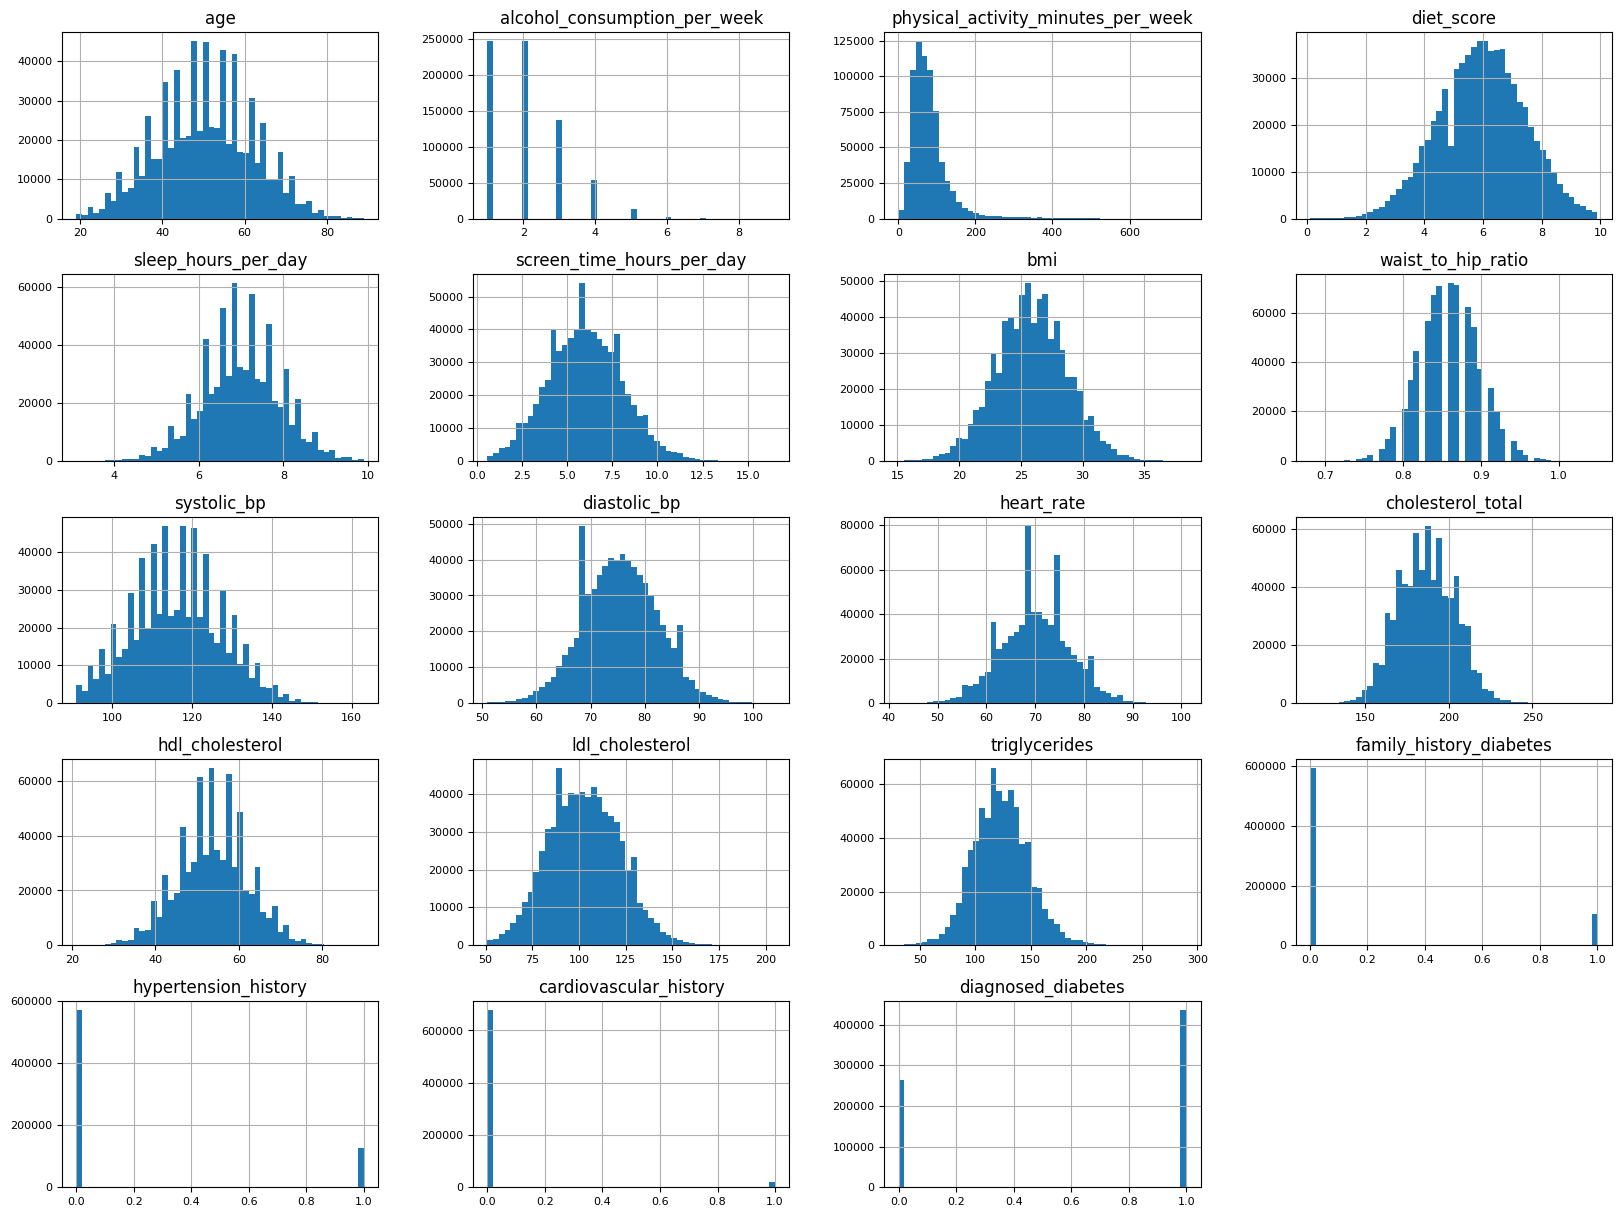

In [13]:
training_data.hist(figsize=(20, 15), bins=50, xlabelsize=8, ylabelsize=8)

In [14]:
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
numeric_cols = [col for col, dtype in training_data.items() if col not in categorical_cols]

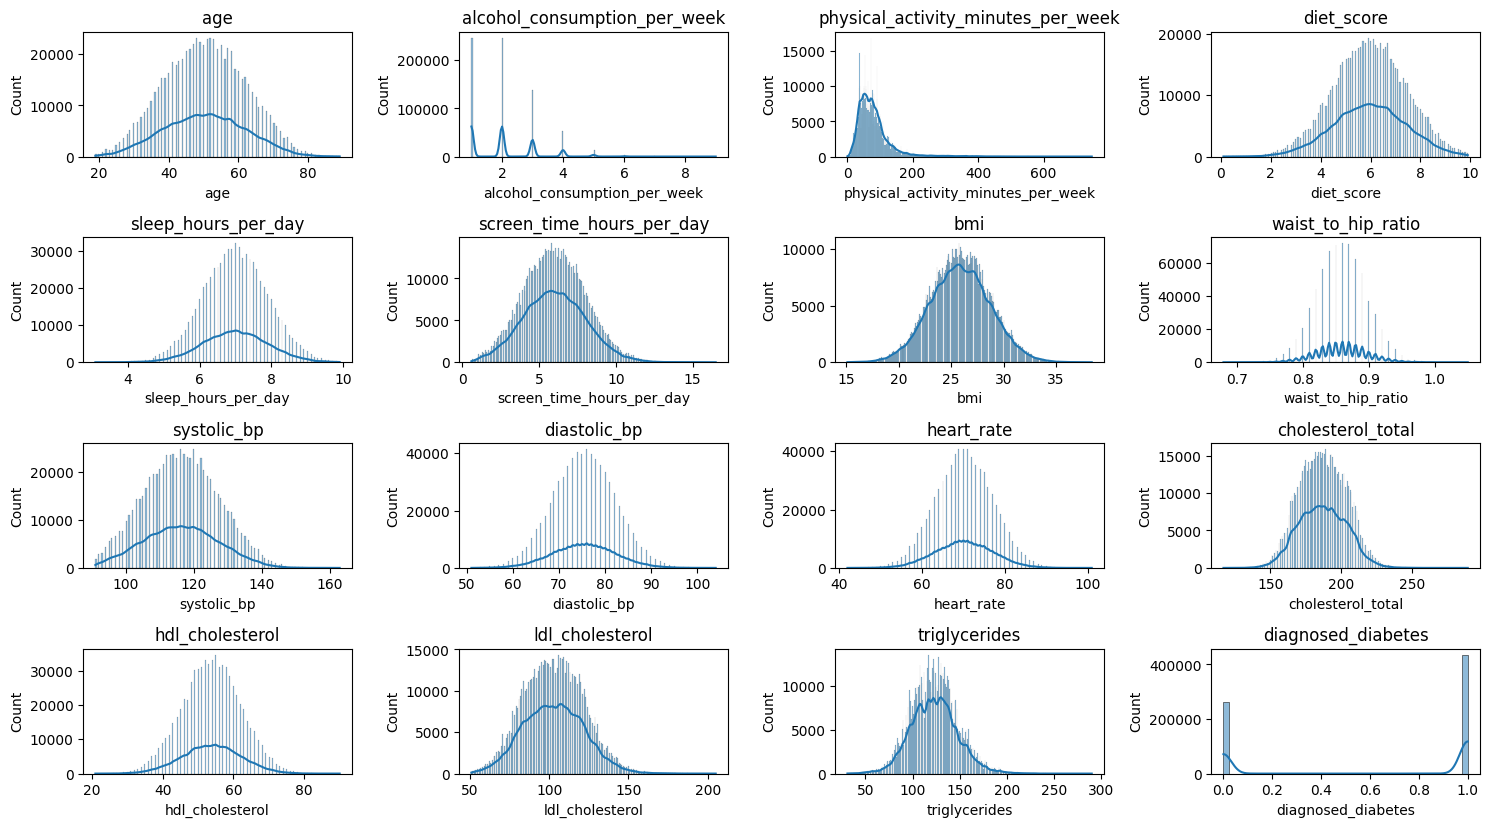

In [15]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(5,4, i)
    sns.histplot(training_data[col], kde=True)
    plt.title(col)
plt.tight_layout()

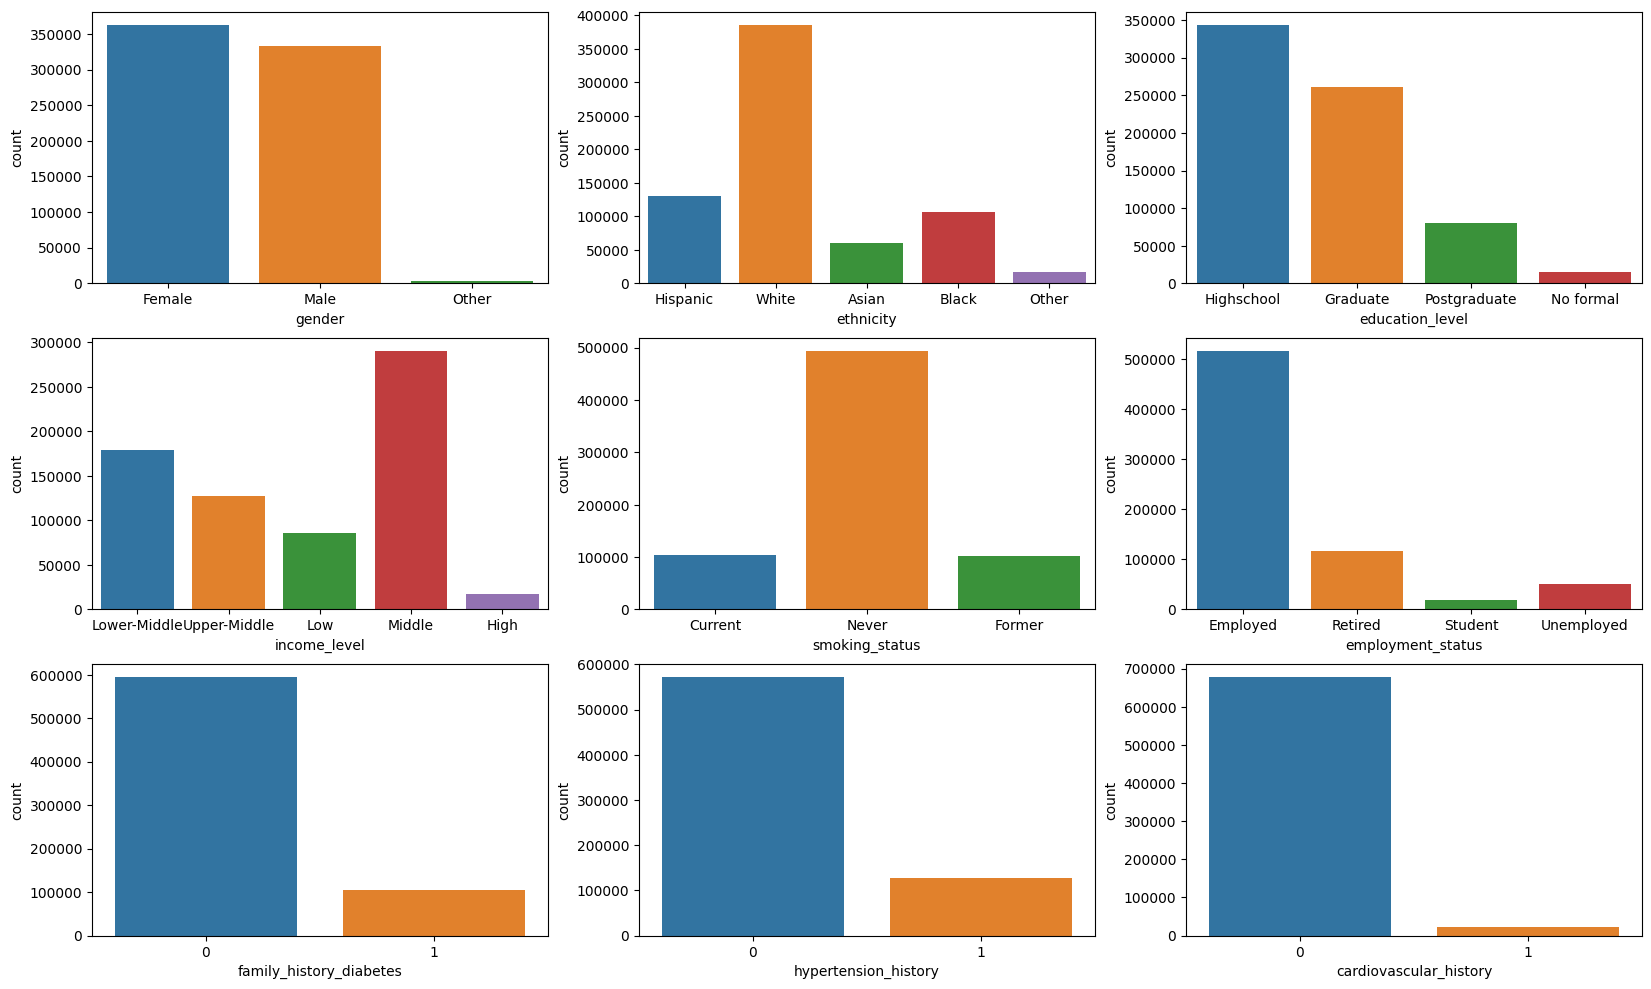

In [16]:
plot_count = 0
plt.figure(figsize=(20, 12))
for cat in categorical_cols:
    ax = plt.subplot(3, 3, plot_count+1)
    sns.countplot(data=training_data, x=cat)
    plot_count += 1
plt.show()

### Multivariate Distribution

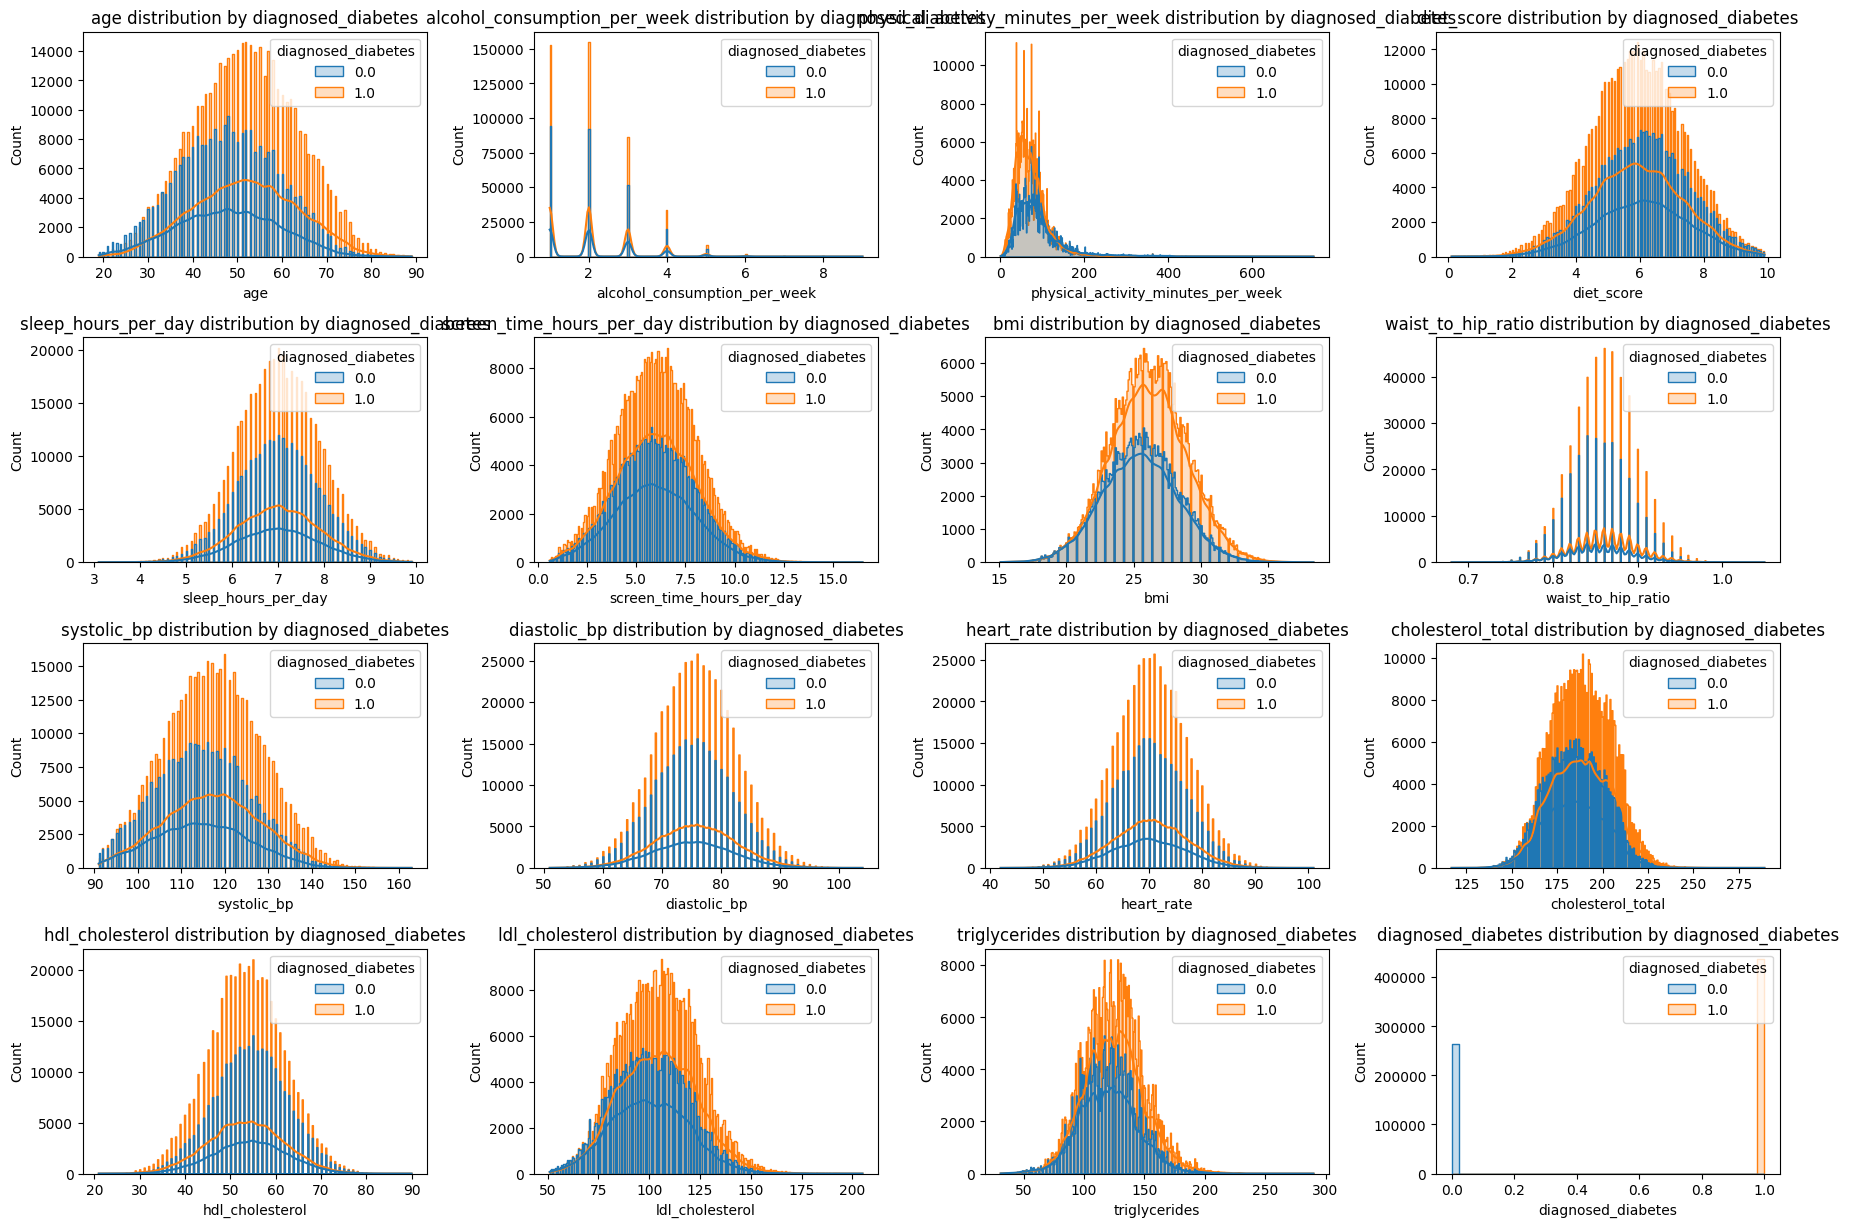

In [17]:
plt.figure(figsize=(18,15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.histplot(data=training_data, x=col, hue='diagnosed_diabetes', kde=True, element="step")
    plt.title(f"{col} distribution by diagnosed_diabetes")
plt.tight_layout()

### Computing the Group stats

In [18]:
training_data.groupby('diagnosed_diabetes')[numeric_cols].agg(['mean','median','std']).T

diagnosed_diabetes                                0.0         1.0
age                                mean     47.943484   51.820056
                                   median   48.000000   52.000000
                                   std      11.352802   11.593097
alcohol_consumption_per_week       mean      2.068379    2.074849
                                   median    2.000000    2.000000
                                   std       1.052838    1.045364
physical_activity_minutes_per_week mean     91.411873   73.473245
                                   median   79.000000   65.000000
                                   std      60.302019   43.428555
diet_score                         mean      6.058035    5.906678
                                   median    6.100000    5.900000
                                   std       1.464877    1.459453
sleep_hours_per_day                mean      6.998129    7.004660
                                   median    7.000000    7.000000
                                   std       0.904101    0.900570
screen_time_hours_per_day          mean      5.965346    6.041372
                                   median    5.900000    6.000000
                                   std       2.027223    2.019437
bmi                                mean     25.486175   26.109489
                                   median   25.500000   26.100000
                                   std       2.832044    2.852350
waist_to_hip_ratio                 mean      0.854806    0.861159
                                   median    0.850000    0.860000
                                   std       0.037914    0.037819
systolic_bp                        mean    114.776907  117.211202
                                   median  115.000000  117.000000
                                   std      10.806463   11.031119
diastolic_bp                       mean     75.122464   75.633393
                                   median   75.000000   76.000000
                                   std       6.821817    6.820969
heart_rate                         mean     69.954747   70.296482
                                   median   70.000000   70.000000
                                   std       6.969243    6.917040
cholesterol_total                  mean    184.922531  187.964860
                                   median  185.000000  188.000000
                                   std      16.526515   16.749371
hdl_cholesterol                    mean     54.389237   53.481125
                                   median   54.000000   54.000000
                                   std       8.162087    8.310381
ldl_cholesterol                    mean    100.391167  104.425668
                                   median  100.000000  104.000000
                                   std      18.800903   18.994343
triglycerides                      mean    120.197593  124.825022
                                   median  120.000000  124.000000
                                   std      24.277571   24.852648
diagnosed_diabetes                 mean      0.000000    1.000000
                                   median    0.000000    1.000000
                                   std       0.000000    0.000000

### Correlation matrix & Feature Relationship

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Text(0.5, 1.0, 'Correlation matrix')

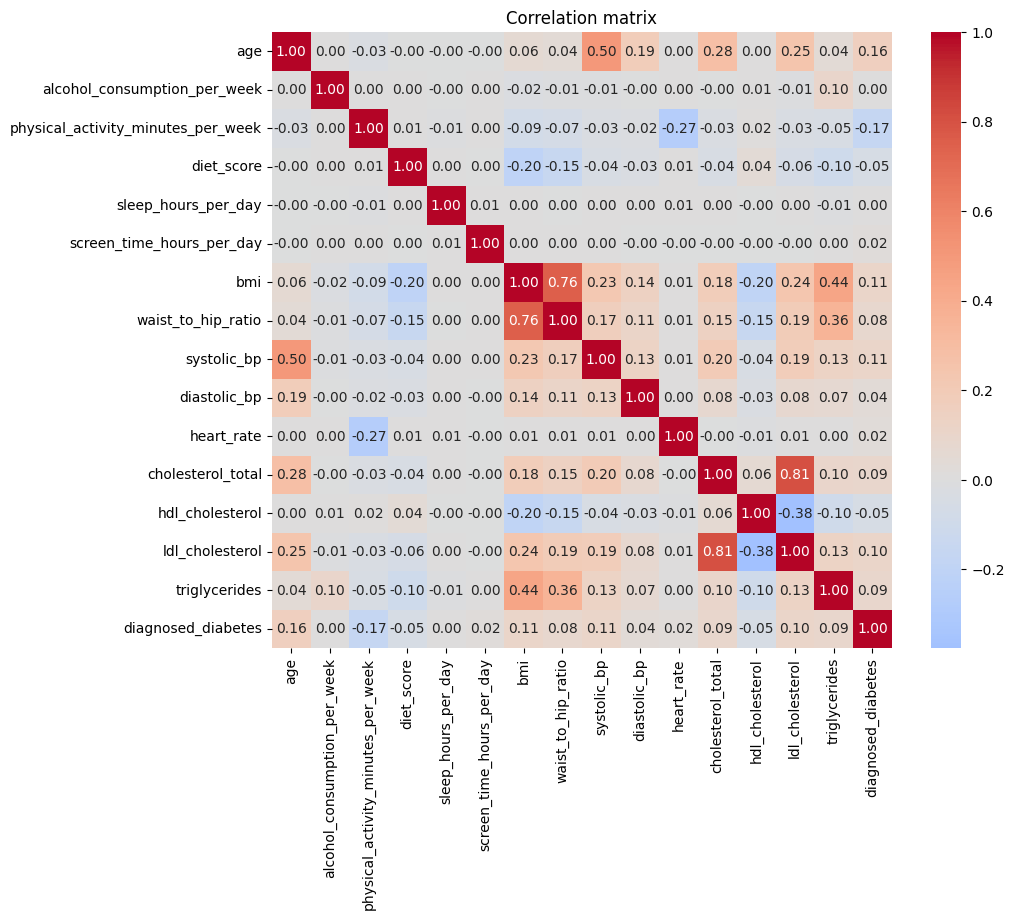

In [19]:
plt.figure(figsize=(10,8))
corr = training_data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation matrix")

In [20]:
df = training_data.copy()

In [21]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_features = [c for c in numerical_features if c != 'diagnosed_diabetes']


categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [22]:
X = df.drop(columns=['diagnosed_diabetes'])
y = df['diagnosed_diabetes']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Handling Outliers for Numerical Features

In [23]:
def clip_outliers(series, k=1.5):
    q1, q3 = series.quantile([0.25,0.75])
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return series.clip(lower, upper)

for col in numerical_features:
    X[col] = clip_outliers(X[col])

#### Creating meaningful features

##### Creating Interactive features

In [24]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # BMI + Age interaction
        X['bmi_age_interaction'] = X['bmi'] * X['age']

        # Blood pressure ratio (strongly correlated with metabolic syndrome)
        X['bp_ratio'] = X['systolic_bp'] / X['diastolic_bp']

        # Sedentary index
        X['sedentary_index'] = X['screen_time_hours_per_day'] / X['physical_activity_minutes_per_week'].replace(0,1)

        #Blood Pressure Interaction
        X['bp_interaction'] = X['systolic_bp'] * X['diastolic_bp']

        #Lipid Profile Ration
        X['chol_hdl_ratio'] = X['cholesterol_total'] / X['hdl_cholesterol']

        # Cholesterol risk score
        X['cholesterol_risk'] = X['ldl_cholesterol'] / X['hdl_cholesterol']

        # BMI Physical Activity Interaction
        X['bmi_activity_interaction'] = X['bmi'] * X['physical_activity_minutes_per_week']

        # Screen time x Sleep
        X['screen_sleep_interaction'] = X['screen_time_hours_per_day'] * X['sleep_hours_per_day']


        # Domain driven derived features

        # bmi categories
        X['bmi_category'] = pd.cut(X['bmi'], bins=[0,18.5,25,30,100], labels=['under','normal','over','obese'])

        # Age group
        X['age_group'] = pd.cut(X['age'], bins=[0, 30, 45, 60, 100], labels=['young', 'mid_age', 'senior', 'elderly'])

        # Sleep Quality Category
        X['sleep_quality'] = pd.cut(X['sleep_hours_per_day'], bins=[0, 5, 7, 9, 24], labels=['poor', 'fair', 'good', 'excellent'])

        #Physical Activity Flag
        X['activity_level'] = pd.cut(X['physical_activity_minutes_per_week'], bins=[0, 150, 300, 10000], labels=['low', 'moderate', 'high'])
        # X = pd.get_dummies(X, columns=['activity_level'], drop_first=True)

        #Waist to hip Ratio Threshold
        X['abdominal_obesity'] = (X['waist_to_hip_ratio'] > 0.90).astype(int)

        #Hypertension Flag
        X['hypertension_flag'] = ((X['systolic_bp'] >= 130) | (X['diastolic_bp'] >= 80)).astype(int)

        #High Cholesterol Risk Flag
        X['high_cholesterol_flag'] = (X['cholesterol_total'] >= 240).astype(int)

        return X

##### Encoding the binary features

In [25]:
# binary_features = [
#     'abdominal_obesity','hypertension_flag','high_cholesterol_flag',
#     'family_history_diabetes','hypertension_history','cardiovascular_history'
# ]

# for col in binary_features:
#     X[col] = X[col].astype(int)

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


#### Numeric Pipeline

In [27]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### Categorical Pipeline

In [28]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#### Combining Preprocessing 

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

#### Baseline Model - LogisticRegression

In [30]:
log_reg_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineering()),
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        max_iter=100,
        class_weight='balanced',
        random_state=42
    ))
])

In [31]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ))
])

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=15,                 # start small
    scoring='roc_auc',
    cv=3,                      # reduce CV folds
    verbose=2,
    random_state=42,
    n_jobs=-1                  # parallelize CV safely
)

In [32]:
#Training 
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering', FeatureEngineering()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'alcohol_consumption_per_week',
                                                   'physical_activity_minutes_per_week',
                                                   'diet_score',
                                                   'sleep_hours_per_day',
                                                   'screen_time_hours_per_day',
                                                   'bmi...
                                                   'family_history_diabetes',
                                                   'hypertension_history',
                                                   'cardiovascular_history']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ethnicity',
                                                   'education_level',
                                                   'income_level',
                                                   'smoking_status',
                                                   'employment_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [33]:
rf_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 5.0min
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time= 6.5min
[CV] END model__max_depth=5, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  57.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=100; total time= 3.0min
[CV] END model__max_depth=5, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=200; total time= 1.6min
[CV] END model__max_depth=5, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=100; total time=  50.3s
[CV] EN

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'alcohol_consumption_per_week',
                                                                                'physical_activity_minutes_per_week',
                                                                                'diet_score',
                                                                                'sleep_hours_per_day',
                                                                                'screen_time_hours_per_day',
                                                                                'bmi',
                                                                                'waist_to_...
                                                                                'employment_status'])])),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     n_jobs=1,
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 20],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [34]:
#Evaluation on validation data

from sklearn.metrics import roc_auc_score

y_pred_proba_lr = log_reg_pipeline.predict_proba(X_valid)[:, 1]
# y_pred_proba_rf = rf_model.predict_proba(X_valid)[:, 1]


roc_auc_lr = roc_auc_score(y_valid, y_pred_proba_lr)
# roc_auc_rf = roc_auc_score(y_valid, y_pred_proba_rf)

print("Logistic Regression ROC AUC:", roc_auc_lr)
# print("Random Forest ROC AUC: ", roc_auc_rf)

Logistic Regression ROC AUC: 0.6948553390847085


In [35]:
best_rf = rf_random_search.best_estimator_

In [36]:
print("Best ROC AUC:", rf_random_search.best_score_)
print("Best Parameters:")
print(rf_random_search.best_params_)

Best ROC AUC: 0.698127040643699
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}


In [37]:
test_data = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv", index_col = 0)

In [38]:
# test_proba = rf_model.predict_proba(test_data)[:, 1]
test_proba = best_rf.predict_proba(test_data)[:, 1]

[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time= 5.8min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time= 1.5min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 2.7min
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 2.7min
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 2.3min
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 2.3min
[CV] END model__max_depth=5, model__max_features=log2, model__min_s

In [39]:
submission = pd.DataFrame({
    "id": test_data.index,   # or use an existing ID column if present
    "diagnosed_diabetes": test_proba
})

In [40]:
submission.to_csv("submissions.csv", index=False)